In [1]:
import pandas as pd
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, roc_curve, classification_report
import warnings
import matplotlib.pyplot as plt
warnings.filterwarnings("ignore")

# Initial Model

## Data Loading

In [ ]:
df = pd.read_csv(r"/content/german_credit_data.csv")
df.head()

,Unnamed: 0,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,0,67,male,2,own,NaN,little,1169,6,radio/TV,good
1,1,22,female,2,own,little,moderate,5951,48,radio/TV,bad
2,2,49,male,1,own,little,NaN,2096,12,education,good
3,3,45,male,2,free,little,little,7882,42,furniture/equipment,good
4,4,53,male,2,free,little,little,4870,24,car,bad


## EAD

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Unnamed: 0        1000 non-null   int64 
 1   Age               1000 non-null   int64 
 2   Sex               1000 non-null   object
 3   Job               1000 non-null   int64 
 4   Housing           1000 non-null   object
 5   Saving accounts   817 non-null    object
 6   Checking account  606 non-null    object
 7   Credit amount     1000 non-null   int64 
 8   Duration          1000 non-null   int64 
 9   Purpose           1000 non-null   object
 10  Risk              1000 non-null   object
dtypes: int64(5), object(6)
memory usage: 86.1+ KB


In [5]:
df['target'] = df['Risk'].map({'bad': 1, 'good': 0})

In [6]:
df.isna().sum()


Unnamed: 0            0
Age                   0
Sex                   0
Job                   0
Housing               0
Saving accounts     183
Checking account    394
Credit amount         0
Duration              0
Purpose               0
Risk                  0
target                0
dtype: int64

In [7]:
df = df.dropna().reset_index(drop=True)

In [8]:
df.isna().sum()

Unnamed: 0          0
Age                 0
Sex                 0
Job                 0
Housing             0
Saving accounts     0
Checking account    0
Credit amount       0
Duration            0
Purpose             0
Risk                0
target              0
dtype: int64

In [9]:
df.drop(columns='Unnamed: 0', inplace=True)

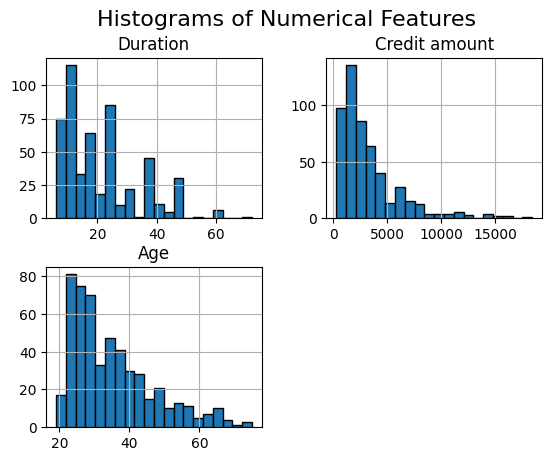

In [10]:
df[['Duration', 'Credit amount', 'Age']].hist(bins=20, edgecolor="black")
plt.suptitle("Histograms of Numerical Features", fontsize=16)
plt.show()


In [11]:
df.describe()

,Age,Job,Credit amount,Duration,target
count,522.000000,522.000000,522.000000,522.000000,522.000000
mean,34.888889,1.875479,3278.745211,21.339080,0.442529
std,11.787918,0.682811,2929.155177,12.474079,0.497163
min,19.000000,0.000000,276.000000,6.000000,0.000000
25%,26.000000,2.000000,1297.500000,12.000000,0.000000
50%,31.500000,2.000000,2326.500000,18.000000,0.000000
75%,41.000000,2.000000,3971.250000,26.750000,1.000000
max,75.000000,3.000000,18424.000000,72.000000,1.000000


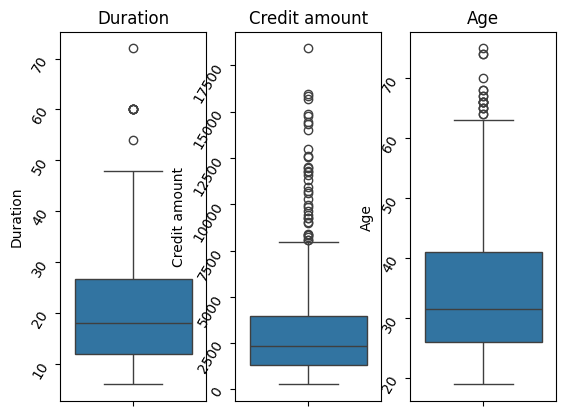

In [12]:
plt.figsize = (10,6)
for i, col in enumerate(['Duration', 'Credit amount', 'Age']):
    plt.subplot(1, 3,i+1)
    sns.boxplot(y=df[col])
    plt.title(col)
    plt.yticks(rotation=59)
plt.show()

In [13]:
df.query("Duration >=50")

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk,target
18,63,male,2,own,little,little,6836,60,business,bad,1
54,58,male,2,rent,little,moderate,15945,54,business,bad,1
176,24,female,3,own,moderate,moderate,7408,60,car,bad,1
199,60,female,3,free,moderate,moderate,14782,60,vacation/others,bad,1
358,24,male,2,own,moderate,moderate,5595,72,radio/TV,bad,1
378,27,male,3,own,little,moderate,14027,60,car,bad,1
489,42,male,2,free,little,moderate,6288,60,education,bad,1
507,36,male,2,rent,little,little,7297,60,business,bad,1


## Model Building

In [14]:
#Onehotcode encoding
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
feature = ['Sex', 'Job', 'Housing', 'Saving accounts', 'Checking account',
           'Purpose']
processer = ColumnTransformer(
    transformers=[
        ("cat",OneHotEncoder(sparse_output=True, drop='first'), feature)],
     remainder="passthrough")
encoded_array = processer.fit_transform(df)
encoded_col_names = processer.named_transformers_['cat'].get_feature_names_out(
    feature)
all_col_names = list(encoded_col_names) + [ a for a in df.columns
                                           if a not in feature]
encoded_df = pd.DataFrame(encoded_array, columns=all_col_names)


In [15]:
encoded_df_ = encoded_df[[a for a in encoded_df.columns if a !="target"
                          and a!="Risk"]]

In [16]:
from sklearn.ensemble import RandomForestClassifier
y = df['target']
X = encoded_df_
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,
                                                    random_state=42)

In [17]:
model = RandomForestClassifier(class_weight="balanced", random_state=42)
model.fit(X_train,y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [18]:
predict = model.predict(X_test)

In [19]:
prediceted_probabilities = model.predict_proba(X_test)[:, 1]

In [20]:
roc_auc = roc_auc_score(y_test, predict)
gini = (2 * roc_auc) - 1
print(f"ROC-AUC Score: {roc_auc:.4f}")
print(f"Gini Coefficient: {gini:.4f}")

ROC-AUC Score: 0.5673
Gini Coefficient: 0.1345


# Optmized Model

## Data Loading

In [ ]:
df = pd.read_csv(r"/content/german_credit_data.csv")
df.head()

,Unnamed: 0,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,0,67,male,2,own,NaN,little,1169,6,radio/TV,good
1,1,22,female,2,own,little,moderate,5951,48,radio/TV,bad
2,2,49,male,1,own,little,NaN,2096,12,education,good
3,3,45,male,2,free,little,little,7882,42,furniture/equipment,good
4,4,53,male,2,free,little,little,4870,24,car,bad


## Feature Selection

In [24]:
#Feature Selection
df['target'] = df['Risk'].map({'bad': 1, 'good': 0})


In [25]:
df = df.dropna().reset_index(drop=True)
df.drop(columns='Unnamed: 0', inplace=True)

In [26]:
#Onehotcode encoding
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
encoding_columns = ['Sex', 'Job', 'Housing', 'Saving accounts',
                    'Checking account',]
processer = ColumnTransformer(
    transformers=[("cat",OneHotEncoder(handle_unknown='ignore',
                                       sparse_output=True, drop='first'),
                   encoding_columns)], remainder="passthrough")
encoded_array = processer.fit_transform(df)
encoded_col_names = processer.named_transformers_['cat'
].get_feature_names_out(encoding_columns)
all_col_names = list(encoded_col_names) + [ a for a in df.columns
                                           if a not in encoding_columns]
encoded_df = pd.DataFrame(encoded_array, columns=all_col_names)
#encoded_df.info()

In [27]:
encoded_df_ = encoded_df[[a for a in encoded_df.columns if a !="target" and
                          a!="Risk"]]

In [28]:
encoded_df.drop(columns='Risk', inplace=True)

In [29]:
df.columns

Index(['Age', 'Sex', 'Job', 'Housing', 'Saving accounts', 'Checking account',
       'Credit amount', 'Duration', 'Purpose', 'Risk', 'target'],
      dtype='object')

In [30]:
from sklearn.ensemble import RandomForestClassifier
y = df['target']
X = encoded_df.drop(columns='target')
if "Purpose" not in encoding_columns:
    X.drop(columns=['Purpose'], inplace=True)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,
                                                    random_state=360)

## Model Building

In [31]:
model = RandomForestClassifier(class_weight='balanced', random_state=360)
model.fit(X_train,y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [32]:
predict = model.predict(X_test)
prediceted_probabilities_ = model.predict_proba(X_test)[:, 1]

In [33]:
# Calculate ROC-AUC Score
roc_auc_ = roc_auc_score(y_test, prediceted_probabilities_)
# Calculate Gini Coefficient (The standard credit risk metric)
gini_ = (2 * roc_auc_) - 1
print(f"ROC-AUC Score: {roc_auc_:.4f}")
print(f"Gini Coefficient: {gini_:.4f}")

ROC-AUC Score: 0.6869
Gini Coefficient: 0.3738


In [34]:
model_summary = pd.DataFrame({"ROC_AUC":[roc_auc,roc_auc_],"Gini":[gini,gini_]},
                             index=["Initial_Model","Optimized_model"])
model_summary

,ROC_AUC,Gini
Initial_Model,0.567273,0.134545
Optimized_model,0.686904,0.373808
